In [1]:
import numpy as np
from utilityFunctions import (
    load_csv_to_matrix_batch,
    compute_color_similarity_distance_batch,
    compute_color_preference_distance_batch,
)
import matplotlib.pyplot as plt

# -------------------------
# Configuration
# -------------------------
folder_path = "raw_data/202411_data"   # <-- adjust if your raw files live elsewhere
unique_colours = np.array([
    '#d2b700', '#db8b08', '#c7512c', '#c13547', '#a03663', '#753a7a',
    '#4b488e', '#005692', '#006a8b', '#007b75', '#008a52', '#9aa400'
])
colour_index = {c: i for i, c in enumerate(unique_colours)}
matrix_size = len(unique_colours)

# -------------------------
# Load raw similarity ratings
# -------------------------
response_type = "similarity"
subject_matrices_similarity_raw = load_csv_to_matrix_batch(
    folder_path, response_type, colour_index, matrix_size
)

# Convert raw ratings → similarity *distance* matrices
subject_matrices_similarity_distance = compute_color_similarity_distance_batch(
    subject_matrices_similarity_raw
)

# -------------------------
# Load raw preference ratings
# -------------------------
response_type = "preference"
subject_matrices_preference_raw = load_csv_to_matrix_batch(
    folder_path, response_type, colour_index, matrix_size
)

# Convert raw ratings → preference *distance* matrices
subject_matrices_preference_distance = compute_color_preference_distance_batch(
    subject_matrices_preference_raw
)

print(f"Loaded {len(subject_matrices_similarity_distance)} similarity distance matrices")
print(f"Loaded {len(subject_matrices_preference_distance)} preference distance matrices")


Order of files being loaded:
raw_data/202411_data/subject_01_551325.csv
raw_data/202411_data/subject_02_5a9b20.csv
raw_data/202411_data/subject_03_5eb05d.csv
raw_data/202411_data/subject_04_609c10.csv
raw_data/202411_data/subject_05_60d129.csv
raw_data/202411_data/subject_06_610814.csv
raw_data/202411_data/subject_07_6171f3.csv
raw_data/202411_data/subject_08_65a3ab.csv
raw_data/202411_data/subject_09_65f13c.csv
raw_data/202411_data/subject_10_65f18d.csv
raw_data/202411_data/subject_11_65fa3b.csv
raw_data/202411_data/subject_12_663180.csv
raw_data/202411_data/subject_13_667c6c.csv
raw_data/202411_data/subject_14_667df4.csv
raw_data/202411_data/subject_15_668110.csv
raw_data/202411_data/subject_16_6681ad.csv
raw_data/202411_data/subject_17_66906a.csv
raw_data/202411_data/subject_18_66a502.csv
raw_data/202411_data/subject_19_6734b5.csv
Order of files being loaded:
raw_data/202411_data/subject_01_551325.csv
raw_data/202411_data/subject_02_5a9b20.csv
raw_data/202411_data/subject_03_5eb05d.

Similarity distances mean=5.122, std=2.094, min=0.000, max=7.000
Preference distances mean=1.678, std=1.131, min=0.000, max=3.500


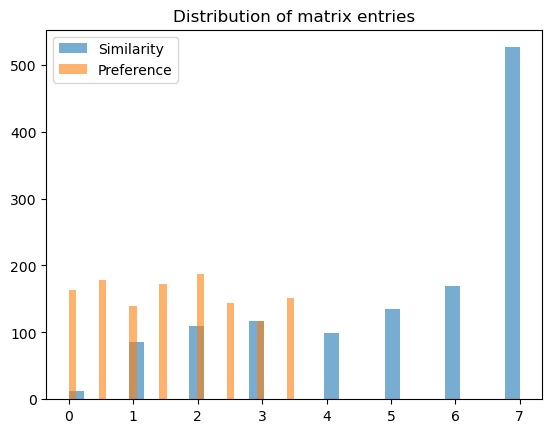

In [2]:
def matrix_stats(mats, name=""):
    values = np.concatenate([m[np.triu_indices_from(m, k=1)] for m in mats])
    print(f"{name} mean={values.mean():.3f}, std={values.std():.3f}, min={values.min():.3f}, max={values.max():.3f}")
    return values

sim_vals = matrix_stats(subject_matrices_similarity_distance, "Similarity distances")
pref_vals = matrix_stats(subject_matrices_preference_distance, "Preference distances")

plt.hist(sim_vals, bins=30, alpha=0.6, label="Similarity")
plt.hist(pref_vals, bins=30, alpha=0.6, label="Preference")
plt.legend(); plt.title("Distribution of matrix entries"); plt.show()
